<a href="https://colab.research.google.com/github/idialloaka-ai/DAILYCHALLENGE/blob/master/Daily_challenge_W7D2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Installation des dépendances et téléchargement des ressources NLTK/spaCy

In [2]:
import requests
import re
import nltk
import spacy
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')
nltk.download('maxent_ne_chunker')
nltk.download('words')

# Chargement du modèle spaCy
try:
    nlp = spacy.load('en_core_web_sm')
except:
    !python -m spacy download en_core_web_sm
    nlp = spacy.load('en_core_web_sm')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker.zip.
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.


### 2. Chargement et Nettoyage des textes (Requêtes URL + Regex + Slicing)

In [2]:
import requests
import re

def load_texts(urls):
    corpus = []
    for url in urls:
        response = requests.get(url)
        text = response.text

        # Slicing pour supprimer les en-têtes Project Gutenberg
        start_marker = "*** START OF THE PROJECT GUTENBERG EBOOK"
        end_marker = "*** END OF THE PROJECT GUTENBERG EBOOK"

        start_idx = text.find(start_marker)
        if start_idx != -1:
            # On avance après la ligne du marqueur
            text = text[text.find('\n', start_idx) + 1:]

        end_idx = text.find(end_marker)
        if end_idx != -1:
            text = text[:end_idx]

        # Nettoyage des non-mots (ponctuation/chiffres) via Regex
        text = re.sub(r'[^a-zA-Z\s]', '', text)
        # Normalisation des espaces
        text = re.sub(r'\s+', ' ', text).strip()

        corpus.append(text.lower())
    return corpus

urls = [
    "https://www.gutenberg.org/files/11/11-0.txt",  # Alice's Adventures in Wonderland
    "https://www.gutenberg.org/files/12/12-0.txt",  # Through the Looking-Glass
    "https://www.gutenberg.org/cache/epub/620/pg620.txt" # A Tangled Tale
]

book_titles = ["Alice's Adventures", "Through the Looking-Glass", "A Tangled Tale"]
raw_corpus = load_texts(urls)

# Affichage des 200 premiers caractères
for i, text in enumerate(raw_corpus):
    print(f"--- {book_titles[i]} (200 premiers caractères) ---")
    print(text[:200] + "...\n")

--- Alice's Adventures (200 premiers caractères) ---
illustration alices adventures in wonderland by lewis carroll the millennium fulcrum edition contents chapter i down the rabbithole chapter ii the pool of tears chapter iii a caucusrace and a long tal...

--- Through the Looking-Glass (200 premiers caractères) ---
illustration through the lookingglass and what alice found there by lewis carroll the millennium fulcrum edition dramatis person as arranged before commencement of game white red pieces pawns pawns pi...

--- A Tangled Tale (200 premiers caractères) ---
produced by an anonymous project gutenberg volunteer sylvie and bruno by lewis carroll is all our life then but a dream seen faintly in the goldern gleam athwart times dark resistless stream bowed to ...



### 3. Tokenisation et suppression des Stopwords

In [5]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk

# Téléchargement des ressources nécessaires (incluant punkt_tab pour corriger l'erreur)
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

tokenized_corpus = [word_tokenize(text) for text in raw_corpus]
filtered_corpus = []

for i, tokens in enumerate(tokenized_corpus):
    print(f"--- {book_titles[i]} (150 premiers tokens) ---")
    print(tokens[:150])

    # Suppression des stopwords
    filtered = [w for w in tokens if w not in stop_words]
    filtered_corpus.append(filtered)

    # Vérification
    print(f"Taille avant: {len(tokens)} | Taille après stopwords: {len(filtered)}")
    print(f"Mot 'me' présent ? {'me' in filtered}\n")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


--- Alice's Adventures (150 premiers tokens) ---
['illustration', 'alices', 'adventures', 'in', 'wonderland', 'by', 'lewis', 'carroll', 'the', 'millennium', 'fulcrum', 'edition', 'contents', 'chapter', 'i', 'down', 'the', 'rabbithole', 'chapter', 'ii', 'the', 'pool', 'of', 'tears', 'chapter', 'iii', 'a', 'caucusrace', 'and', 'a', 'long', 'tale', 'chapter', 'iv', 'the', 'rabbit', 'sends', 'in', 'a', 'little', 'bill', 'chapter', 'v', 'advice', 'from', 'a', 'caterpillar', 'chapter', 'vi', 'pig', 'and', 'pepper', 'chapter', 'vii', 'a', 'mad', 'teaparty', 'chapter', 'viii', 'the', 'queens', 'croquetground', 'chapter', 'ix', 'the', 'mock', 'turtles', 'story', 'chapter', 'x', 'the', 'lobster', 'quadrille', 'chapter', 'xi', 'who', 'stole', 'the', 'tarts', 'chapter', 'xii', 'alices', 'evidence', 'chapter', 'i', 'down', 'the', 'rabbithole', 'alice', 'was', 'beginning', 'to', 'get', 'very', 'tired', 'of', 'sitting', 'by', 'her', 'sister', 'on', 'the', 'bank', 'and', 'of', 'having', 'nothing', 'to

### 4. Stemming (Porter) vs Lemmatization (spaCy)

In [7]:
from nltk.stem import PorterStemmer
import spacy

# Charger le modèle spaCy si ce n'est pas déjà fait
try:
    nlp = spacy.load('en_core_web_sm')
except:
    import os
    os.system('python -m spacy download en_core_web_sm')
    nlp = spacy.load('en_core_web_sm')

stemmer = PorterStemmer()

for i, tokens in enumerate(filtered_corpus):
    # 5. Stemming
    stems = [stemmer.stem(w) for w in tokens]
    print(f"--- {book_titles[i]} (50 premiers Porter Stems) ---")
    print(stems[:50])

    # 6. Lemmatization via spaCy (sur le texte filtré)
    doc = nlp(" ".join(tokens[:100])) # Limité aux 100 premiers pour l'affichage
    lemmas = [token.lemma_ for token in doc]
    print(f"\n--- {book_titles[i]} (50 premiers spaCy Lemmas) ---")
    print(lemmas[:50])
    print("-"*30)

--- Alice's Adventures (50 premiers Porter Stems) ---
['illustr', 'alic', 'adventur', 'wonderland', 'lewi', 'carrol', 'millennium', 'fulcrum', 'edit', 'content', 'chapter', 'rabbithol', 'chapter', 'ii', 'pool', 'tear', 'chapter', 'iii', 'caucusrac', 'long', 'tale', 'chapter', 'iv', 'rabbit', 'send', 'littl', 'bill', 'chapter', 'v', 'advic', 'caterpillar', 'chapter', 'vi', 'pig', 'pepper', 'chapter', 'vii', 'mad', 'teaparti', 'chapter', 'viii', 'queen', 'croquetground', 'chapter', 'ix', 'mock', 'turtl', 'stori', 'chapter', 'x']

--- Alice's Adventures (50 premiers spaCy Lemmas) ---
['illustration', 'alice', 'adventure', 'wonderland', 'lewis', 'carroll', 'millennium', 'fulcrum', 'edition', 'content', 'chapter', 'rabbithole', 'chapter', 'ii', 'pool', 'tear', 'chapter', 'iii', 'caucusrace', 'long', 'tale', 'chapter', 'iv', 'rabbit', 'send', 'little', 'bill', 'chapter', 'v', 'advice', 'caterpillar', 'chapter', 'vi', 'pig', 'pepper', 'chapter', 'vii', 'mad', 'teaparty', 'chapter', 'viii', 'q

### Analyse du texte : 1. Nuages de mots
Affichage des mots les plus fréquents pour chaque livre de Lewis Carroll.

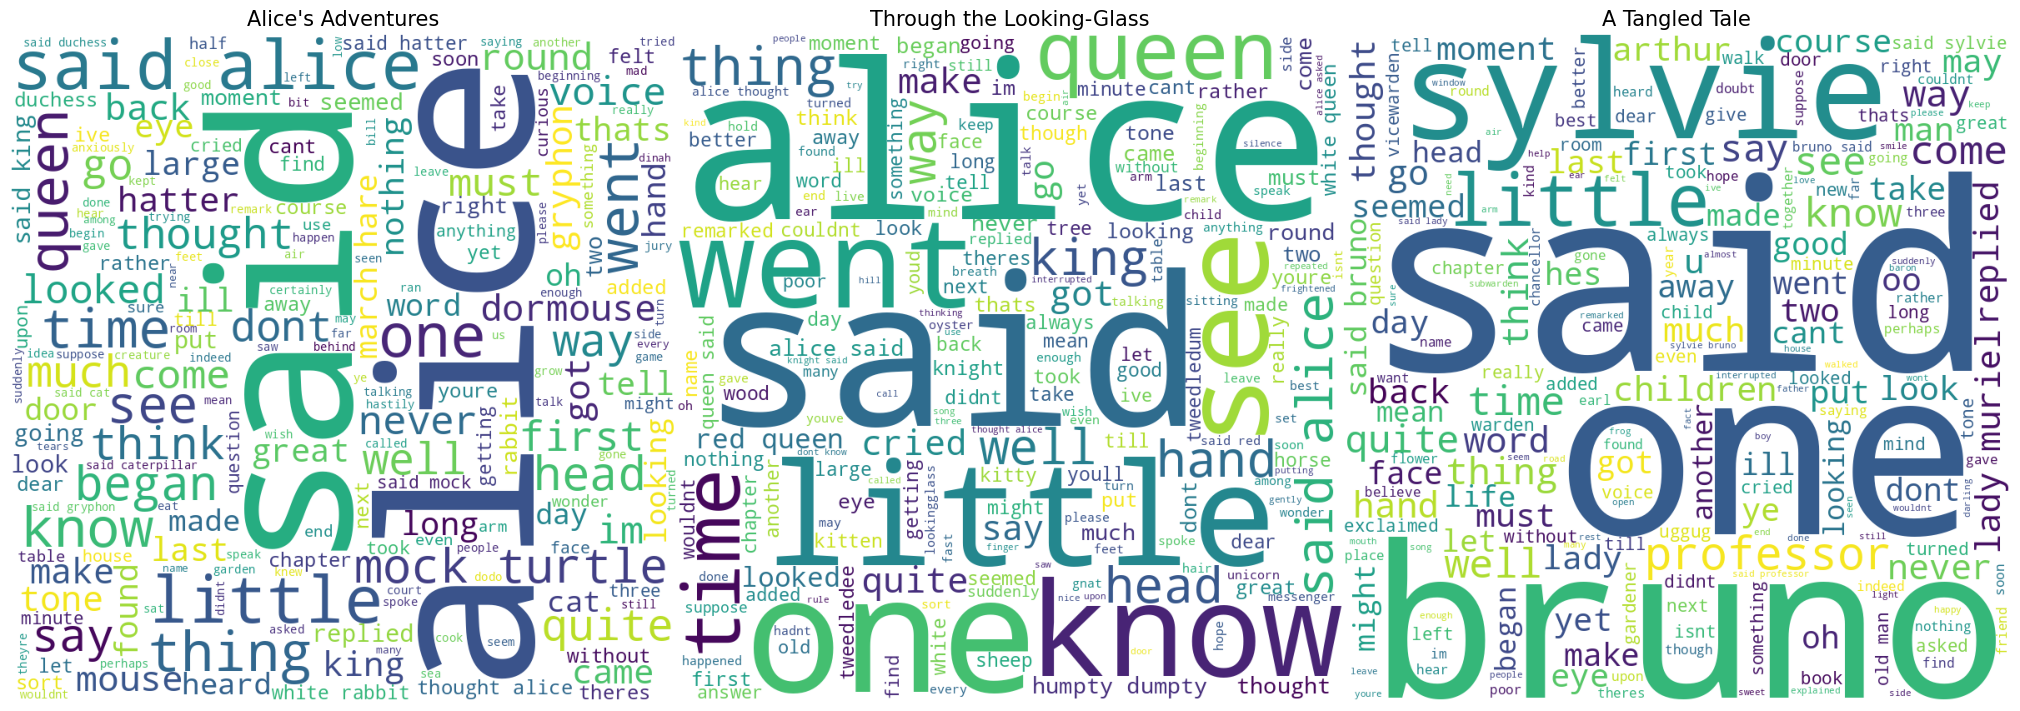

In [8]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Configuration de l'affichage
fig, axes = plt.subplots(1, 3, figsize=(20, 10))

for i, tokens in enumerate(filtered_corpus):
    # Conversion de la liste de tokens en une seule chaîne de caractères
    text_for_cloud = " ".join(tokens)

    # Génération du nuage de mots
    wordcloud = WordCloud(width=800, height=800,
                          background_color='white',
                          min_font_size=10).generate(text_for_cloud)

    # Affichage
    axes[i].imshow(wordcloud)
    axes[i].set_title(book_titles[i], fontsize=15)
    axes[i].axis("off")

plt.tight_layout(pad=0)
plt.show()

### Analyse du texte : 2, 3 & 4. Sac de mots (BoW) et Diagrammes circulaires
Identification des 5 mots les plus fréquents par document et visualisation.

Taille du vocabulaire : 8606


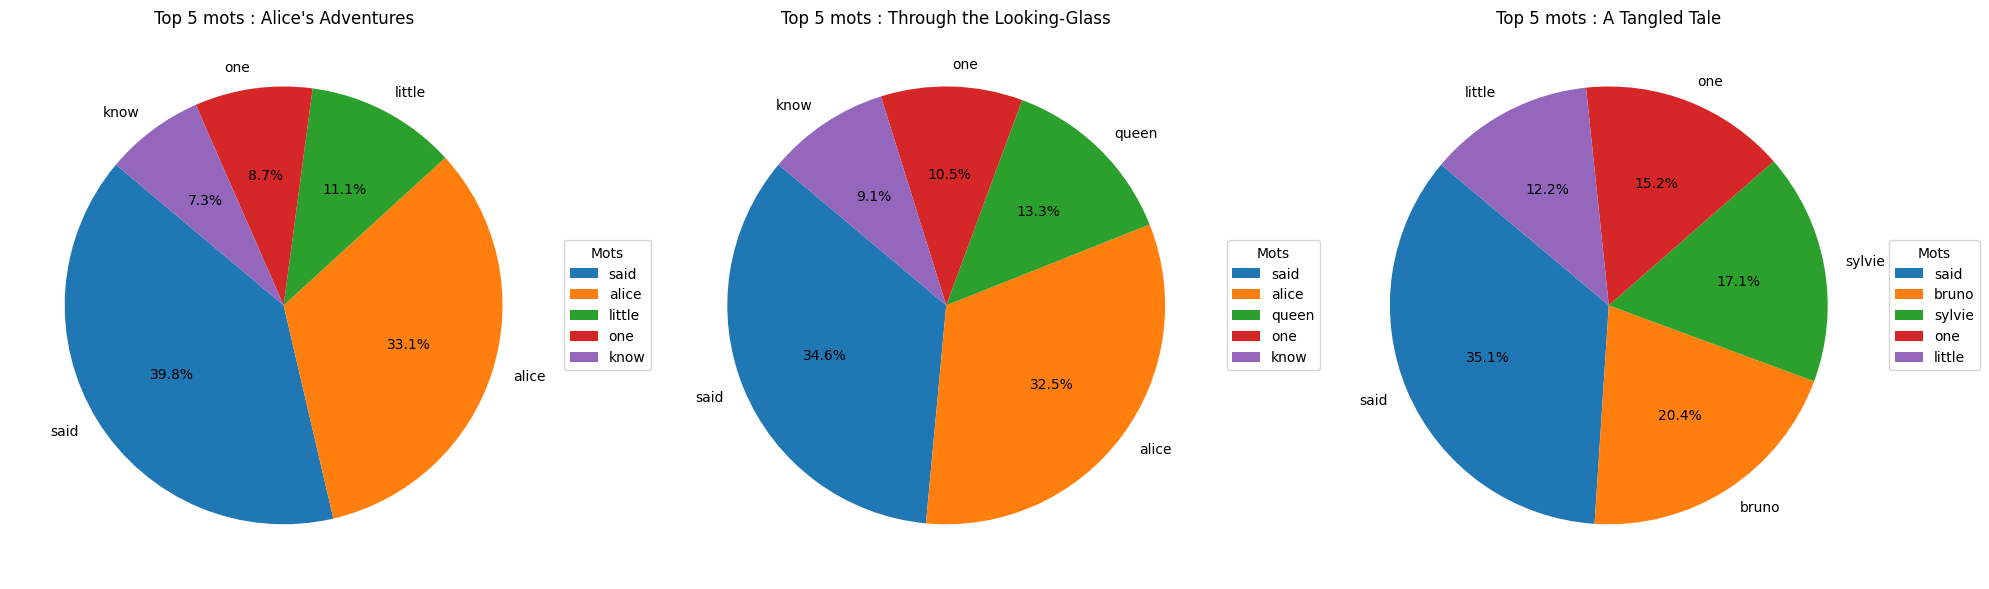


--- Détails techniques du BoW ---
Document 0 (Alice's Adventures) : 2625 mots uniques trouvés.
Document 1 (Through the Looking-Glass) : 3025 mots uniques trouvés.
Document 2 (A Tangled Tale) : 6717 mots uniques trouvés.


In [9]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

# Préparation du texte (on utilise le texte après suppression des stopwords)
processed_corpus = [" ".join(tokens) for tokens in filtered_corpus]

# Initialisation du CountVectorizer
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(processed_corpus)
words = vectorizer.get_feature_names_out()

# Affichage du BoW (extraits)
print(f"Taille du vocabulaire : {len(words)}")

# Création des graphiques
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for i, title in enumerate(book_titles):
    # Récupération des fréquences pour le document i
    word_counts = X[i].toarray()[0]
    df_words = pd.DataFrame({'word': words, 'count': word_counts})
    top5 = df_words.sort_values(by='count', ascending=False).head(5)

    # Génération du diagramme circulaire
    axes[i].pie(top5['count'], labels=top5['word'], autopct='%1.1f%%', startangle=140)
    axes[i].set_title(f"Top 5 mots : {title}")
    axes[i].legend(top5['word'], title="Mots", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

plt.tight_layout()
plt.show()

# Réponse à la question 3 de l'analyse : Identification des numéros
print("\n--- Détails techniques du BoW ---")
for i in range(len(book_titles)):
    print(f"Document {i} ({book_titles[i]}) : {X[i].nnz} mots uniques trouvés.")